# Comparative analysis of dimension reduction methods and rebalancing techniques in mental health text classification


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import re
import time
from pathlib import Path
from collections import namedtuple

import kagglehub 
from kagglehub import KaggleDatasetAdapter

import spacy
from sklearn.feature_extraction import text
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, StratifiedGroupKFold, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import f1_score, accuracy_score,classification_report,confusion_matrix,make_scorer
from sklearn.pipeline import Pipeline
from sklearn.decomposition import TruncatedSVD, NMF
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler

from langdetect import detect, DetectorFactory
from langdetect.lang_detect_exception import LangDetectException

In [2]:
KEEP_WORDS = {'i','me','my','myself','we','our','ours', 'not', 'no','never','neither','nor'}

CONTRACTION_MAP = {
    "isn't": "is not", "aren't": "are not", "can't": "cannot", 
    "can't've": "cannot have", "could've": "could have", "couldn't": "could not",
    "didn't": "did not", "doesn't": "does not", "don't": "do not",
    "hadn't": "had not", "hasn't": "has not", "haven't": "have not",
    "he'd": "he would", "he'll": "he will", "he's": "he is",
    "i'd": "i would", "i'll": "i will", "i'm": "i am", "i've": "i have",
    "it's": "it is", "let's": "let us", "mightn't": "might not",
    "mustn't": "must not", "shan't": "shall not", "she'd": "she would",
    "she'll": "she will", "she's": "she is", "shouldn't": "should not",
    "they'd": "they would", "they'll": "they will", "they're": "they are",
    "they've": "they have", "weren't": "were not", "what'll": "what will",
    "what're": "what are", "what's": "what is", "what've": "what have",
    "where's": "where is", "who'd": "who would", "who'll": "who will",
    "who're": "who are", "who's": "who is", "who've": "who have",
    "won't": "will not", "wouldn't": "would not", "you'd": "you would",
    "you'll": "you will", "you're": "you are", "you've": "you have", 
    "that's":"that is"
}

In [3]:
processed_file_exists = Path(Path.cwd(), "mental_health_preprocessed.csv").is_file()
dataset_handle = "priyangshumukherjee/mental-health-text-classification-dataset"

if not processed_file_exists:

  # The main unbalanced training data
  df_unbalanced = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    dataset_handle,
    "mental_heath_unbanlanced.csv"
  )

  print("Unbalanced Data Loaded. Shape:", df_unbalanced.shape)
  print(df_unbalanced.columns)
  print(df_unbalanced.head())

In [4]:
if not processed_file_exists:
    class_counts = df_unbalanced['status'].value_counts()
    class_pct = df_unbalanced['status'].value_counts(normalize=True) * 100

    print("Class Distribution:")
    for label, count in class_counts.items():
        print(f"{label}: {count} ({class_pct[label]:.2f}%)")

    print("\nMissing values:")
    print(df_unbalanced.isnull().sum())

## Data cleaning process

In [5]:
if not processed_file_exists:
    duplicate_count = df_unbalanced.duplicated().sum()
    print(f"Duplicate across the whole rows: {duplicate_count}")

    text_duplicates = df_unbalanced.duplicated(subset=['text']).sum()
    print(f"Duplicate text entries: {text_duplicates}")

    if text_duplicates > 0:
        print("Some duplicate entries:")
        display(df_unbalanced[df_unbalanced.duplicated(subset=['text'], keep=False)].sort_values(by='text').head(5))

    df_unbalanced = df_unbalanced.drop_duplicates(subset=['text'], keep='first')
    print(f"\nDataset size after removing duplicates: {df_unbalanced.shape[0]}")

In [6]:
if not processed_file_exists:
    DetectorFactory.seed = 42

    def is_english(text):
        if len(str(text)) < 3:
            return False
        try:
            return detect(text) == 'en'
        except LangDetectException:
            return False
        
    print("Filtering non-English text...")
    df_unbalanced = df_unbalanced[df_unbalanced['text'].apply(is_english)].copy()
    print(f"Dataset size after language filtering: {len(df_unbalanced)}")

As part of the data cleaning process, records with duplicate text and those not in English are removed. This results in a reduction in records from **49,612** when the dataset was initially loaded to **46,295**.

### Table showing what usually changes and what stays the same when using Lemmatization.
| Word Category | Original Word(s) | Lemma (Root Form) | Transformation Logic |
| :--- | :--- | :--- | :--- |
| **Verbs** | feeling, felt, feels | **feel** | Reduces all tenses and aspects to the base infinitive. |
| **Nouns** | crises, mice, women | **crisis, mouse, woman** | Converts plural forms to their singular dictionary root. |
| **Adjectives** | better, saddest | **good, sad** | Reduces comparative/superlative forms to the base adjective. |
| **Adverbs** | suddenly, quietly | **suddenly, quietly** | Usually remains the same as adverbs are often base lemmas. |
| **Pronouns** | me, my, myself | **me, my, myself** | **Customized:** Skiping lemmatization here to keep "self-referential" markers. |
| **Mixed** | sleeping, slept | **sleep** | Distinguishes between "sleep" (noun) and "sleep" (verb). |

In [7]:
if not processed_file_exists:
    nlp = spacy.load("en_core_web_sm", disable=['parser', 'ner'])

    def expand_contractions(text, mapping):
        pattern = re.compile(r'\b(' + '|'.join(mapping.keys()) + r')\b')
        return pattern.sub(lambda x: mapping[x.group()], text)

    def preprocess_text(text):
        text = text.lower()

        text = expand_contractions(text, CONTRACTION_MAP)
        text = text.replace('/',' ').replace('-', ' ')
        
        text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
        text = re.sub(r'\@\w+|\#','', text)
        text = re.sub(r'[^a-z\s]', '', text)

        doc = nlp(text)

        tokens = []
        for token in doc:
            if token.text in KEEP_WORDS:
                tokens.append(token.text)
            elif not token.is_stop and not token.is_space:
                tokens.append(token.lemma_)
        return " ".join(tokens)

    print("Starting Preprocessing ... ")
    df_unbalanced['cleaned_text'] = df_unbalanced['text'].apply(preprocess_text)
    print("Preprocessing Complete")

    df_unbalanced.to_csv('mental_health_preprocessed.csv', index=False)

To preserve the semantic polarity of the statements (so "not feeling good" does not become "feel good," which is the exact opposite meaning), the standard stopword removal process was modified to retain negation terms (e.g., 'not', 'no', 'never'). 

It is also very important to exclude first-person singular pronouns from the stopword list due to self-referential processing (SRP). SRP is crucial for the formation of self-awareness, social cognition, and emotional regulation, as imbalances often contribute to psychiatric conditions such as depression. 


In [8]:
df_unbalanced = pd.read_csv('mental_health_preprocessed.csv')

if 'Unnamed: 0' in df_unbalanced.columns:
    df_unbalanced = df_unbalanced.drop(columns=['Unnamed: 0'])

df_unbalanced['cleaned_text'] = df_unbalanced['cleaned_text'].fillna("")
print(f"Loaded {len(df_unbalanced)} records successfully.")

df_unbalanced = df_unbalanced[df_unbalanced['cleaned_text'].str.strip() != ""].copy()
print(f"Records after removal of empty strings {len(df_unbalanced)}.")

df_unbalanced['word_count'] = df_unbalanced['cleaned_text'].apply(lambda x: len(x.split()))

short_rows = df_unbalanced[df_unbalanced['word_count'] < 3].shape[0]
print(f"Records with fewer than 3 words: {short_rows}")

df_unbalanced = df_unbalanced[df_unbalanced['word_count'] >= 3].copy()
df_unbalanced = df_unbalanced.drop(columns=['word_count'])

print(f"Final record count: {len(df_unbalanced)}")

Loaded 46295 records successfully.
Records after removal of empty strings 46193.
Records with fewer than 3 words: 1873
Final record count: 44320


Class Distribution:
Normal: 14010 (31.61%)
Depression: 14003 (31.60%)
Suicidal: 11081 (25.00%)
Anxiety: 5226 (11.79%)


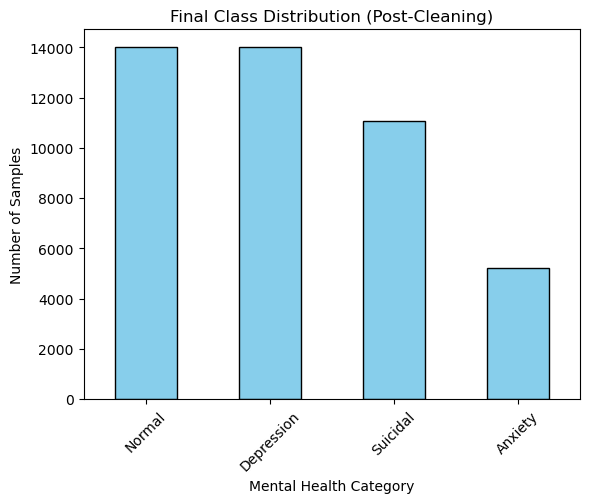

In [9]:
class_counts = df_unbalanced['status'].value_counts()
class_pct = df_unbalanced['status'].value_counts(normalize=True) * 100

print("Class Distribution:")
for label, count in class_counts.items():
    print(f"{label}: {count} ({class_pct[label]:.2f}%)")

class_counts.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Final Class Distribution (Post-Cleaning)')
plt.ylabel('Number of Samples')
plt.xlabel('Mental Health Category')
plt.xticks(rotation=45)
plt.show()

## Vectorization

In [10]:
def make_tfidf():
    return TfidfVectorizer(
        max_features=30000,
        ngram_range=(1,2),
        min_df=2,
        max_df=0.90,
    )

def build_pipeline(dimred, sampler, clf):
    return ImbPipeline(steps=[
        ("tfidf", make_tfidf()),
        ("dimred", dimred if dimred is not None else "passthrough"),
        ("sampler", sampler if sampler is not None else "passthrough"),
        ("clf", clf),
    ])

def build_pipeline_vec(dimred, sampler, clf):
    return ImbPipeline(steps=[
        ("dimred", dimred if dimred is not None else "passthrough"),
        ("sampler", sampler if sampler is not None else "passthrough"),
        ("clf", clf),
    ])

def evaluate(estimator, X_eval, y_eval, label_encoder: LabelEncoder):
    y_pred = estimator.predict(X_eval)
    
    macro_f1 = f1_score(y_eval, y_pred, average="macro")
    weighted_f1 = f1_score(y_eval, y_pred, average="weighted")
    acc = accuracy_score(y_eval, y_pred)

    report_dist = classification_report(
        y_eval,
        y_pred,
        target_names=label_encoder.classes_,
        output_dict=True,
        digits=4
    )

    per_class_recall = {}
    for c in label_encoder.classes_:
        per_class_recall[f"recall_{c}"] = report_dist[c]["recall"]
        per_class_recall[f"f1_{c}"] = report_dist[c]["f1-score"]

    cm = confusion_matrix(y_eval, y_pred)
    cm_normalized = confusion_matrix(y_eval, y_pred, normalize='true')

    result = {
        "macro_f1":macro_f1,
        "weighted_f1":weighted_f1,
        "accuracy":acc,
        "confusion_matrix": cm,
        "confusion_matrix_normalized": cm_normalized,
        "classification_report_text": classification_report(
            y_eval, y_pred, target_names=label_encoder.classes_, output_dict=True, digits=4
        )
    }

    result.update(per_class_recall)
    return result 
    
X = df_unbalanced['cleaned_text']
y = df_unbalanced['status']

le = LabelEncoder()
y_enc = le.fit_transform(y)
print("Classes:", list(le.classes_))

X_train, X_val, y_train, y_val = train_test_split(
    X, y_enc,
    test_size=0.15,
    stratify=y_enc,
    random_state=42
)

tfidf_global = make_tfidf()
X_train_vec = tfidf_global.fit_transform(X_train)
X_val_vec = tfidf_global.transform(X_val)
print(f"TF-IDF vectorized: {X_train_vec.shape[0]} train, {X_val_vec.shape[0]} val, {X_train_vec.shape[1]} features")

Classes: ['Anxiety', 'Depression', 'Normal', 'Suicidal']
TF-IDF vectorized: 37672 train, 6648 val, 30000 features


In [11]:

# The external Test Set data
df_test_ext = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  dataset_handle,
  "mental_health_combined_test.csv"
)

print("External Test Set Data Loaded. Shape:", df_test_ext.shape)
print(df_test_ext.columns)
print(df_test_ext.head())

print(f"Train size: {len(X_train)}")
print(f"Validation size: {len(X_val)}")
print(f"External Test size: {len(df_test_ext)}")


External Test Set Data Loaded. Shape: (992, 2)
Index(['text', 'status'], dtype='object')
                                                text   status
0  i don't understand whats wrong with me. i don'...  Anxiety
1  usually when i have anxiety just chatting with...  Anxiety
2  well, i've had anxiety and panic syndrome for ...  Anxiety
3  for the most minimal of things, like standing ...  Anxiety
4  i stay away from family and live with my roomm...  Anxiety
Train size: 37672
Validation size: 6648
External Test size: 992


To ensure rigorous evaluation and prevent data leakage, the TfidfVectorizer was fitted exclusively on the training data. Validation and external test sets were subsequently transformed using the fixed vocabulary and IDF weights derived from the training phase

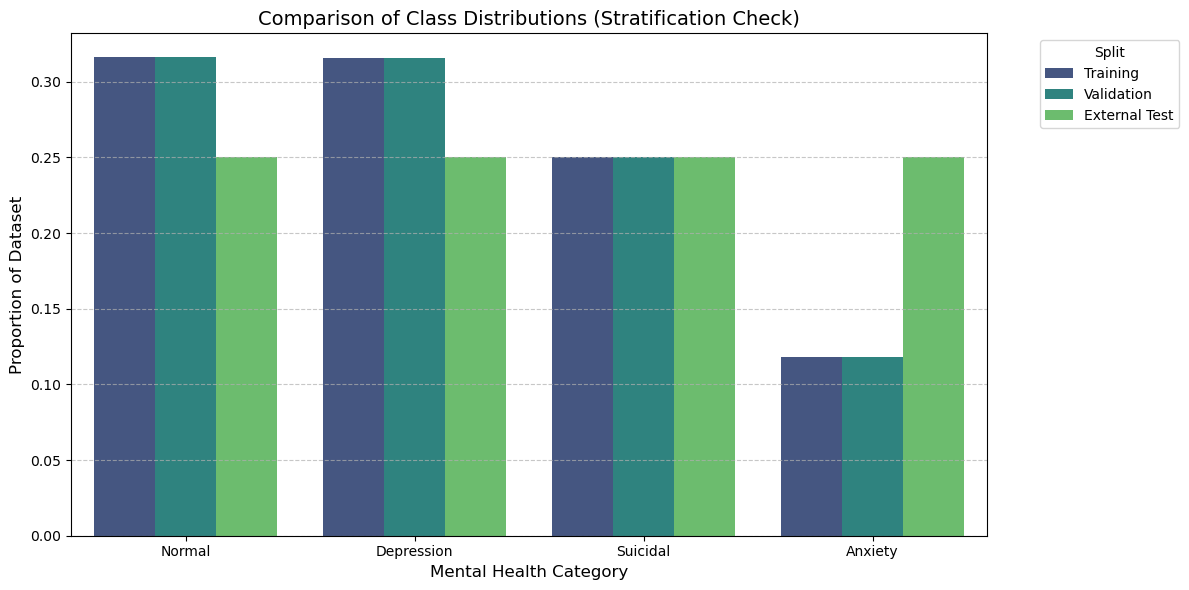

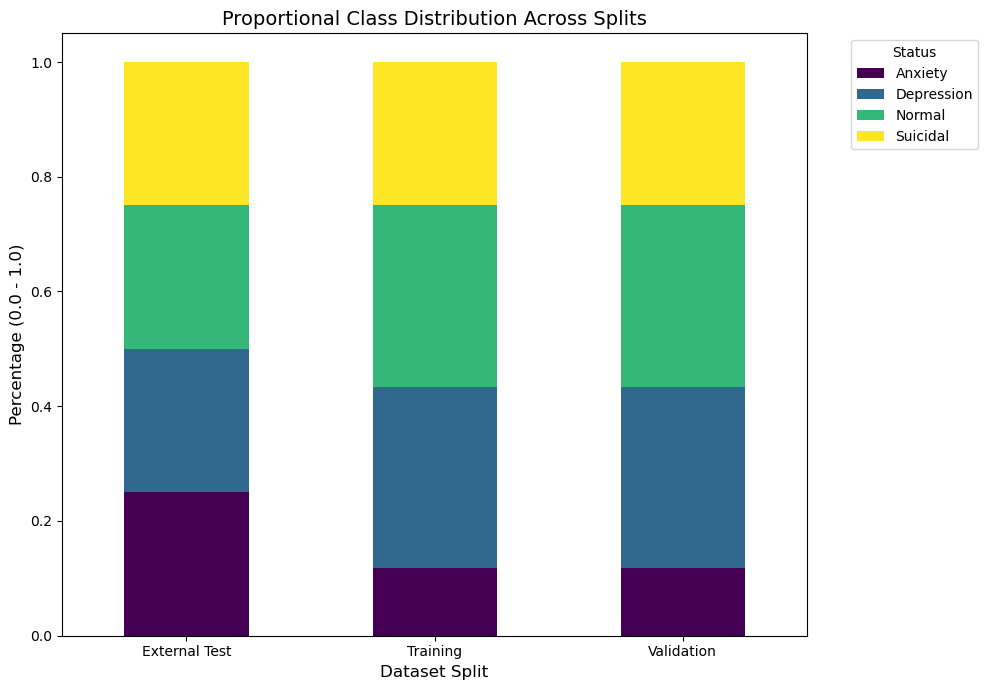

In [12]:
def get_dist_df(labels, set_name):
    dist = pd.Series(labels).value_counts(normalize=True).reset_index()
    dist.columns = ['Status', 'Percentage']
    dist['Dataset'] = set_name
    return dist


train_labels = le.inverse_transform(y_train)
val_labels = le.inverse_transform(y_val)
test_labels = df_test_ext['status']


train_dist = get_dist_df(train_labels, 'Training')
val_dist = get_dist_df(val_labels, 'Validation')
test_dist = get_dist_df(test_labels, 'External Test')

comparison_df = pd.concat([train_dist, val_dist, test_dist])

plt.figure(figsize=(12, 6))
sns.barplot(data=comparison_df, x='Status', y='Percentage', hue='Dataset', palette='viridis')

plt.title('Comparison of Class Distributions (Stratification Check)', fontsize=14)
plt.ylabel('Proportion of Dataset', fontsize=12)
plt.xlabel('Mental Health Category', fontsize=12)
plt.legend(title='Split', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

pivot_df = comparison_df.pivot(index='Dataset', columns='Status', values='Percentage')

pivot_df.plot(kind='bar', stacked=True, figsize=(10, 7), colormap='viridis')

plt.title('Proportional Class Distribution Across Splits', fontsize=14)
plt.ylabel('Percentage (0.0 - 1.0)', fontsize=12)
plt.xlabel('Dataset Split', fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='Status', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

In [ ]:
def grid_experiment(exp_id, pipeline, param_grid, X_train, y_train, X_val, y_val, le: LabelEncoder, n_jobs=-1):
    f1_macro_scorer = make_scorer(f1_score, average='macro')
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    t0 = time.time()
    gs = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid,
        scoring=f1_macro_scorer,
        cv=cv,
        n_jobs=n_jobs,
        verbose=0,
        refit=True,
        return_train_score=False
    )
    
    gs.fit(X_train, y_train)
    train_time = time.time() - t0

    best = gs.best_estimator_
    best_params = gs.best_params_
    best_cv_mean = gs.best_score_
    best_cv_std = gs.cv_results_["std_test_score"][gs.best_index_]

    val_metrics = evaluate(best, X_val, y_val, le)

    row = {
        "exp_id": exp_id,
        "best_params": best_params,
        "cv_macro_f1_mean": float(best_cv_mean),
        "cv_macro_f1_std": float(best_cv_std),
        "val_macro_f1": float(val_metrics["macro_f1"]),
        "val_weighted_f1": float(val_metrics["weighted_f1"]),
        "val_accuracy": float(val_metrics["accuracy"]),
        "train_time_sec": float(train_time),
        "val_confusion_matrix": val_metrics["confusion_matrix"],
        "val_classification_report": val_metrics["classification_report_text"],
    }
    
    row.update({k: float(v) for k, v in val_metrics.items() if k.startswith("recall_")})

    return best, row

def make_experiments():
    experiments = []

    Experiment = namedtuple("Experiment", ["id", "description", "pipe", "grid", "n_jobs"], defaults=[-1])

    experiments.append(Experiment(
        id="E01",
        description="Linear SVC",
        pipe=build_pipeline_vec(dimred=None, sampler=None, clf=LinearSVC()),
        grid={"clf__C": [0.5, 0.1, 2.0]}
    ))

    experiments.append(Experiment(
        id="E02",
        description="Logistic Regression",
        pipe=build_pipeline_vec(
            dimred=None, 
            sampler=None, 
            clf=LogisticRegression(max_iter=2000, solver="saga")
        ),
        grid={"clf__C": [0.5, 0.1, 2.0]}
    ))

    experiments.append(Experiment(
        id="E03",
        description="Multinomial NB",
        pipe=build_pipeline_vec(dimred=None, sampler=None, clf=MultinomialNB()),
        grid={"clf__alpha": [0.5, 1.0]}
    ))

    experiments.append(Experiment(
        id="E04",
        description="SelectKBest chi2 + Linear SVC",
        pipe=build_pipeline_vec(dimred=SelectKBest(chi2), sampler=None, clf=LinearSVC(max_iter=10000)),
        grid={
            "dimred__k": [10_000, 20_000],
            "clf__C": [0.1, 0.5, 2.0],
        }
    ))

    experiments.append(Experiment(
        id="E05",
        description="TruncatedSVD/LSA + Linear SVC",
        pipe=build_pipeline_vec(dimred=TruncatedSVD(random_state=42), sampler=None, clf=LinearSVC(max_iter=10000)),
        grid={
            "dimred__n_components": [100, 300],
            "clf__C": [0.1, 0.5, 2.0],
        },
        n_jobs=2
    ))

    """experiments.append(Experiment(
        id="E06",
        description="NMF + Linear SVC",
        pipe=build_pipeline_vec(dimred=NMF(max_iter=400, init="nndsvda", random_state=42), sampler=None, clf=LinearSVC(max_iter=10000)),
        grid={
            "dimred__n_components": [50, 100, 200],
            "clf__C": [0.1, 0.5, 2.0],
        },
        n_jobs=2
    ))"""

    experiments.append(Experiment(
        id="E07",
        description="Linear SVC + class_weight=balanced",
        pipe=build_pipeline_vec(dimred=None, sampler=None, clf=LinearSVC(max_iter=10000, class_weight="balanced")),
        grid={
            "clf__C": [0.1, 0.5, 2.0],
        }
    ))

    experiments.append(Experiment(
        id="E08",
        description="RandomOverSampler + Linear SVC",
        pipe=build_pipeline_vec(dimred=None, sampler=RandomOverSampler(random_state=42), clf=LinearSVC(max_iter=10000)),
        grid={
            "sampler__sampling_strategy": ["auto", "minority"],
            "clf__C": [0.1, 0.5, 2.0],
        }
    ))

    experiments.append(Experiment(
        id="E09",
        description="RandomUnderSampler + Linear SVC",
        pipe=build_pipeline_vec(dimred=None, sampler=RandomUnderSampler(random_state=42), clf=LinearSVC(max_iter=10000)),
        grid={
            "sampler__sampling_strategy": ["auto"],
            "clf__C": [0.1, 0.5, 2.0],
        }
    ))

    experiments.append(Experiment(
        id="E10",
        description="SelectKBest chi2 + class_weight=balanced + Linear SVC",
        pipe=build_pipeline_vec(dimred=SelectKBest(chi2), sampler=None, clf=LinearSVC(max_iter=10000, class_weight="balanced")),
        grid={
            "dimred__k": [10_000, 20_000],
            "clf__C": [0.1, 0.5, 2.0],
        }
    ))

    experiments.append(Experiment(
        id="E11",
        description="TruncatedSVD + class_weight=balanced + Linear SVC",
        pipe=build_pipeline_vec(dimred=TruncatedSVD(random_state=42), sampler=None, clf=LinearSVC(max_iter=10000, class_weight="balanced")),
        grid={
            "dimred__n_components": [100, 300],
            "clf__C": [0.1, 0.5, 2.0],
        },
        n_jobs=2
    ))

    experiments.append(Experiment(
        id="E12",
        description="TruncatedSVD + SMOTE + Linear SVC",
        pipe=build_pipeline_vec(dimred=TruncatedSVD(random_state=42), sampler=SMOTE(random_state=42), clf=LinearSVC(max_iter=10000)),
        grid={
            "dimred__n_components": [100, 300],
            "sampler__k_neighbors": [3, 5],
            "sampler__sampling_strategy": ["auto", "minority"],
            "clf__C": [0.1, 0.5, 2.0],
        },
        n_jobs=2
    ))

    experiments.append(Experiment(
        id="E13",
        description="TruncatedSVD + RandomOverSampler + Linear SVC",
        pipe=build_pipeline_vec(dimred=TruncatedSVD(random_state=42), sampler=RandomOverSampler(random_state=42), clf=LinearSVC(max_iter=10000)),
        grid={
            "dimred__n_components": [100, 300],
            "sampler__sampling_strategy": ["auto", "minority"],
            "clf__C": [0.1, 0.5, 2.0],
        },
        n_jobs=2
    ))

    experiments.append(Experiment(
        id="E14",
        description="TruncatedSVD + class_weight=balanced + Logistic Regression",
        pipe=build_pipeline_vec(
            dimred=TruncatedSVD(random_state=42),
            sampler=None,
            clf=LogisticRegression(class_weight="balanced", max_iter=10000, solver="saga")
        ),
        grid={
            "dimred__n_components": [100, 300],
            "clf__C": [0.1, 0.5, 2.0],
        },
        n_jobs=2
    ))

    return experiments

In [14]:
results = []
fitted = {}

experiments = make_experiments()
for exp in experiments:
    exp_id = exp.id
    print(f"\n****** Running {exp_id} - {exp.description} ******")
    best_estimator, row = grid_experiment(
        exp_id,
        exp.pipe,
        exp.grid,
        X_train_vec,
        y_train,
        X_val_vec,
        y_val,
        le,
        n_jobs=exp.n_jobs
    )
    fitted[exp_id] = best_estimator
    results.append(row)

    for key in ["best_params", "cv_macro_f1_mean", "cv_macro_f1_std", "val_macro_f1"]:
        print(" ".join(key.split("_")).capitalize(), row[key])

df_results = pd.DataFrame(results)
df_results.set_index('exp_id', inplace=True)

df_numeric = df_results.select_dtypes(include=['number'])

focus_cols = ["cv_macro_f1_mean", "val_macro_f1"]
target_cols = ["val_macro_f1", "recall_Anxiety", "recall_Depression", "recall_Normal", "recall_Suicidal"]

styled_df = df_numeric.style.set_properties(
    subset=focus_cols,
    **{'background-color': "#006b8c", 'font-weight': 'bold', 'border-left': '1px solid #d3d3d3', 'border-right': '1px solid #d3d3d3'}
).highlight_max(
    subset=target_cols, color="green", axis=0
)

display(styled_df)


****** Running E01 - Linear SVC ******
Best params {'clf__C': 0.5}
Cv macro f1 mean 0.745008588346091
Cv macro f1 std 0.004482090558669583
Val macro f1 0.7429078627163722

****** Running E02 - Logistic Regression ******
Best params {'clf__C': 2.0}
Cv macro f1 mean 0.7487410097452272
Cv macro f1 std 0.009758544397334359
Val macro f1 0.7445363930778648

****** Running E03 - Multinomial NB ******
Best params {'clf__alpha': 0.5}
Cv macro f1 mean 0.6911963072285843
Cv macro f1 std 0.006296055612743032
Val macro f1 0.6970232321666066

****** Running E04 - SelectKBest chi2 + Linear SVC ******
Best params {'clf__C': 0.5, 'dimred__k': 10000}
Cv macro f1 mean 0.7495253417359424
Cv macro f1 std 0.0046178394537296115
Val macro f1 0.7481910207408498

****** Running E05 - TruncatedSVD/LSA + Linear SVC ******
Best params {'clf__C': 2.0, 'dimred__n_components': 300}
Cv macro f1 mean 0.7423814297265531
Cv macro f1 std 0.0059207280660625835
Val macro f1 0.7436545624260806

****** Running E07 - Linear S

c:\Users\MSI\anaconda3\envs\my-project-env\Lib\site-packages\sklearn\model_selection\_validation.py:490: FitFailedWarning: 
15 fits failed out of a total of 30.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
4 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\MSI\anaconda3\envs\my-project-env\Lib\site-packages\sklearn\model_selection\_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\MSI\anaconda3\envs\my-project-env\Lib\site-packages\sklearn\base.py", line 1336, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\MSI\anaconda3\envs\my-project-env\Lib\site-packag

Best params {'clf__C': 0.1, 'sampler__sampling_strategy': 'auto'}
Cv macro f1 mean 0.7326989124517231
Cv macro f1 std 0.006876571183973016
Val macro f1 0.7359800083346524

****** Running E10 - SelectKBest chi2 + class_weight=balanced + Linear SVC ******
Best params {'clf__C': 0.1, 'dimred__k': 20000}
Cv macro f1 mean 0.7506740258658017
Cv macro f1 std 0.0045949029518510265
Val macro f1 0.7509003554887752

****** Running E11 - TruncatedSVD + class_weight=balanced + Linear SVC ******
Best params {'clf__C': 2.0, 'dimred__n_components': 300}
Cv macro f1 mean 0.7421772848398769
Cv macro f1 std 0.006275370953065755
Val macro f1 0.7421806775531008

****** Running E12 - TruncatedSVD + SMOTE + Linear SVC ******
Best params {'clf__C': 2.0, 'dimred__n_components': 300, 'sampler__k_neighbors': 3, 'sampler__sampling_strategy': 'auto'}
Cv macro f1 mean 0.7377273896239112
Cv macro f1 std 0.004803068098598624
Val macro f1 0.7371846121403859

****** Running E13 - TruncatedSVD + RandomOverSampler + Line

,cv_macro_f1_mean,cv_macro_f1_std,val_macro_f1,val_weighted_f1,val_accuracy,train_time_sec,recall_Anxiety,recall_Depression,recall_Normal,recall_Suicidal
exp_id,,,,,,,,,,
E01,0.745009,0.004482,0.742908,0.744148,0.746841,20.979418,0.720663,0.657143,0.915794,0.658845
E02,0.748741,0.009759,0.744536,0.746873,0.748797,8.433390,0.698980,0.680476,0.911513,0.652828
E03,0.691196,0.006296,0.697023,0.708086,0.706378,0.303015,0.535714,0.711905,0.800666,0.660650
E04,0.749525,0.004618,0.748191,0.749195,0.752407,17.608603,0.730867,0.658571,0.924833,0.663057
E05,0.742381,0.005921,0.743655,0.745087,0.748947,192.892655,0.728316,0.643333,0.920076,0.675692
E07,0.750421,0.004259,0.749949,0.749964,0.754663,19.485374,0.792092,0.614762,0.929591,0.692539
E08,0.749116,0.005866,0.749994,0.749853,0.754813,27.293812,0.829082,0.588095,0.921028,0.720217
E09,0.732699,0.006877,0.735980,0.735791,0.742629,2.230445,0.844388,0.545714,0.918173,0.721420
E10,0.750674,0.004595,0.750900,0.750877,0.755566,17.603307,0.794643,0.612857,0.928639,0.698556


The F1 score is the harmonic mean of precision and recall and the macro f1 score which is used is for multi-class classification.
The validation metrics are calculated using the Best Estimator on the Validation set.
### The table shows the used evaluation metrics
| Metric | Description |
| :--- | :--- | 
| **cv_macro_f1_mean** | The average Macro F1-score across all cross-validation folds. |
| **cv_macro_f1_std** | The standard deviation of the F1-score across folds. |
| **val_macro_f1** | The Macro-averaged F1-score on the validation set. |
| **val_weighted_f1**| Unlike Macro F1 (which treats all classes as equal), Weighted F1 gives more "weight" to the classes with more data. |
| **val_accuracy**| The percentage of total correct predictions. |


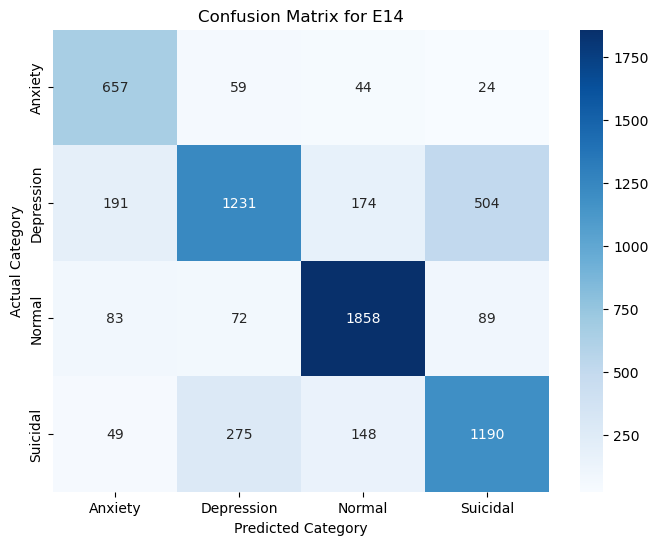

In [30]:
exp_results = results[12] 
cm = exp_results['val_confusion_matrix']

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=le.classes_, 
            yticklabels=le.classes_)

plt.title(f"Confusion Matrix for {exp_results['exp_id']}")
plt.ylabel('Actual Category')
plt.xlabel('Predicted Category')
plt.show()

In [ ]:
# Final evaluation on the balanced external test set

try:
    preprocess_text
except NameError:
    import spacy as _spacy
    if 'nlp' not in dir():
        nlp = _spacy.load("en_core_web_sm", disable=['parser', 'ner'])

    def preprocess_text(text):
        text = text.lower()
        text = expand_contractions(text, CONTRACTION_MAP)
        text = text.replace('/', ' ').replace('-', ' ')
        text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
        text = re.sub(r'\@\w+|\#', '', text)
        text = re.sub(r'[^a-z\s]', '', text)
        doc = nlp(text)
        tokens = []
        for token in doc:
            if token.text in KEEP_WORDS:
                tokens.append(token.text)
            elif not token.is_stop and not token.is_space:
                tokens.append(token.lemma_)
        return " ".join(tokens)

print("Preprocessing external test set...")
df_test_ext['cleaned_text'] = df_test_ext['text'].apply(preprocess_text)
df_test_ext['cleaned_text'] = df_test_ext['cleaned_text'].fillna("")
df_test_ext = df_test_ext[df_test_ext['cleaned_text'].str.strip() != ""].copy()

# Vectorize using the already-fitted TF-IDF — no fitting here (no data leakage)
X_test_ext_vec = tfidf_global.transform(df_test_ext['cleaned_text'])
y_test_ext_enc = le.transform(df_test_ext['status'])

print(f"External test set ready: {X_test_ext_vec.shape[0]} samples, {X_test_ext_vec.shape[1]} features")

# Evaluate every fitted estimator from the experiments
test_results = []
for exp_id, estimator in fitted.items():
    metrics = evaluate(estimator, X_test_ext_vec, y_test_ext_enc, le)
    row = {
        "exp_id": exp_id,
        "test_macro_f1":    float(metrics["macro_f1"]),
        "test_weighted_f1": float(metrics["weighted_f1"]),
        "test_accuracy":    float(metrics["accuracy"]),
    }
    test_results.append(row)
    print(f"{exp_id}: macro_f1={metrics['macro_f1']:.4f}  "
          f"weighted_f1={metrics['weighted_f1']:.4f}  "
          f"accuracy={metrics['accuracy']:.4f}")

df_test_results = pd.DataFrame(test_results).set_index('exp_id')

# Side-by-side comparison: validation vs. balanced external test
df_compare = df_results[["val_macro_f1", "val_weighted_f1", "val_accuracy"]].join(
    df_test_results, how="inner"
)

styled_compare = (
    df_compare.style
    .highlight_max(subset=["val_macro_f1", "test_macro_f1"], color="green", axis=0)
    .set_properties(
        subset=["test_macro_f1", "test_weighted_f1", "test_accuracy"],
        **{"background-color": "#005f73", "font-weight": "bold",
           "border-left": "1px solid #d3d3d3", "border-right": "1px solid #d3d3d3"}
    )
)

print("\nVal vs. Balanced External Test — summary:")
display(styled_compare)



Preprocessing external test set...


NameError: name 'expand_contractions' is not defined

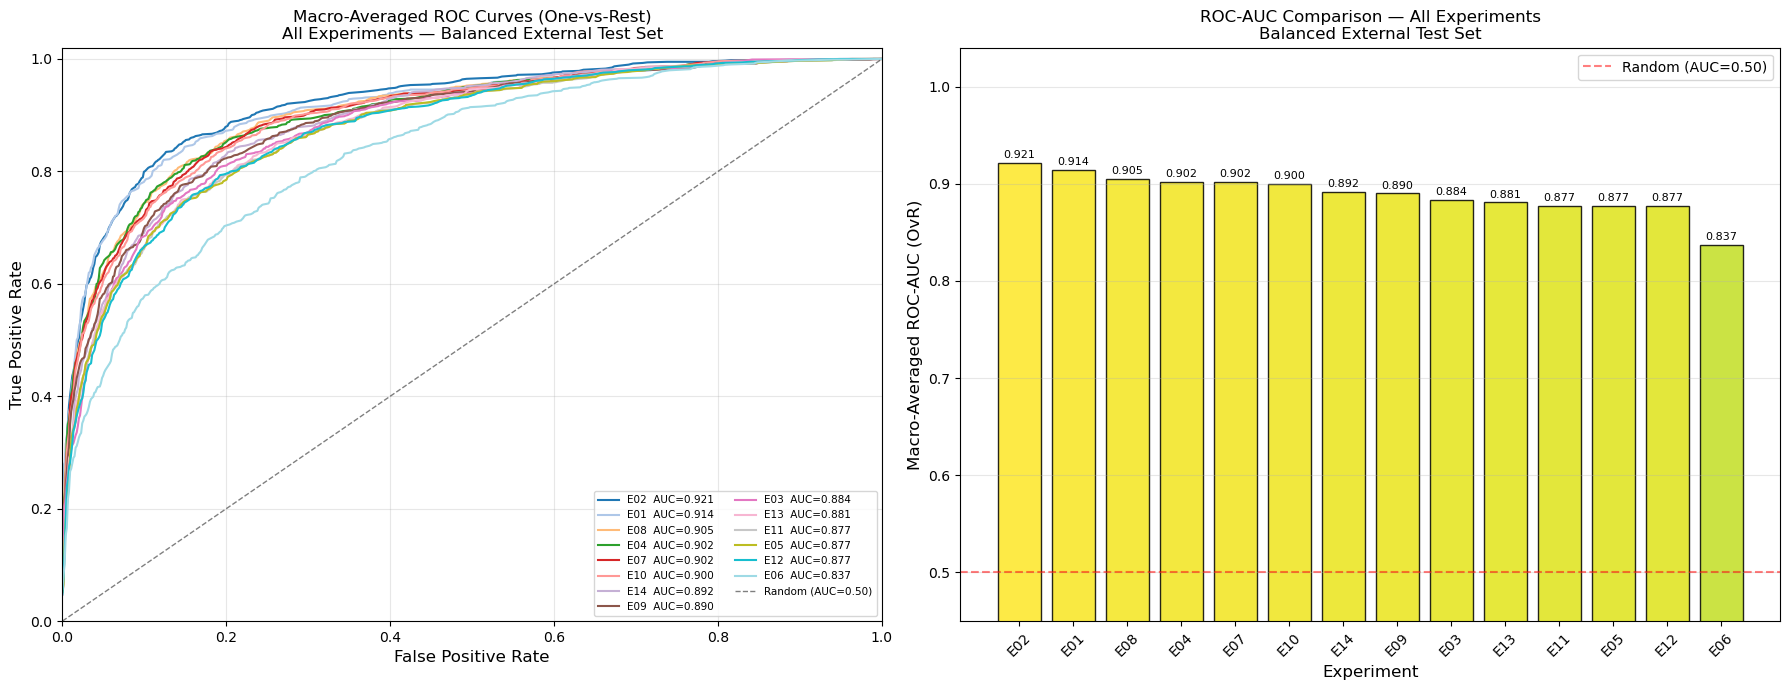

,test_macro_f1,test_weighted_f1,test_accuracy,test_roc_auc_macro
exp_id,,,,
E02,0.7485,0.7485,0.7490,0.9213
E01,0.7617,0.7617,0.7651,0.9140
E08,0.7514,0.7514,0.7550,0.9052
E04,0.7363,0.7363,0.7369,0.9020
E07,0.7463,0.7463,0.7480,0.9019
E10,0.7434,0.7434,0.7450,0.8997
E14,0.7091,0.7091,0.7097,0.8917
E09,0.7300,0.7300,0.7349,0.8901
E03,0.6235,0.6235,0.6310,0.8837


In [ ]:
# ROC-AUC comparison across all experiments
# (evaluated on the balanced external test set)
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

def get_scores_for_roc(estimator, X):
    """Per-class scores for ROC: predict_proba when available (LR, NB),
    otherwise decision_function (LinearSVC) — both work with sklearn's roc_curve."""
    if hasattr(estimator, "predict_proba"):
        return estimator.predict_proba(X)
    return estimator.decision_function(X)

n_classes = len(le.classes_)
y_bin = label_binarize(y_test_ext_enc, classes=list(range(n_classes)))

# ---- Macro-average OvR ROC curve per experiment ----
auc_records = {}
roc_curves   = {}

for exp_id, estimator in fitted.items():
    scores = get_scores_for_roc(estimator, X_test_ext_vec)

    # Common FPR grid for interpolation
    all_fpr = np.unique(np.concatenate([
        roc_curve(y_bin[:, i], scores[:, i])[0]
        for i in range(n_classes)
    ]))

    mean_tpr     = np.zeros_like(all_fpr)
    per_cls_aucs = []
    for i in range(n_classes):
        fpr_i, tpr_i, _ = roc_curve(y_bin[:, i], scores[:, i])
        per_cls_aucs.append(auc(fpr_i, tpr_i))
        mean_tpr += np.interp(all_fpr, fpr_i, tpr_i)

    mean_tpr /= n_classes
    macro_auc = float(np.mean(per_cls_aucs))
    auc_records[exp_id] = macro_auc
    roc_curves[exp_id]  = (all_fpr, mean_tpr)

# ---- Figure: ROC curves (left) + AUC bar chart (right) ----
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

sorted_ids = sorted(auc_records, key=auc_records.get, reverse=True)
palette    = plt.cm.tab20(np.linspace(0, 1, len(sorted_ids)))

# --- Panel 1: ROC curves ---
for exp_id, color in zip(sorted_ids, palette):
    fpr, tpr = roc_curves[exp_id]
    ax1.plot(fpr, tpr, color=color, lw=1.5,
             label=f"{exp_id}  AUC={auc_records[exp_id]:.3f}")

ax1.plot([0, 1], [0, 1], "k--", lw=1, alpha=0.5, label="Random (AUC=0.50)")
ax1.set_xlim([0.0, 1.0])
ax1.set_ylim([0.0, 1.02])
ax1.set_xlabel("False Positive Rate", fontsize=12)
ax1.set_ylabel("True Positive Rate", fontsize=12)
ax1.set_title(
    "Macro-Averaged ROC Curves (One-vs-Rest)\n"
    "All Experiments — Balanced External Test Set",
    fontsize=12
)
ax1.legend(loc="lower right", fontsize=7.5, ncol=2)
ax1.grid(alpha=0.3)

# --- Panel 2: AUC bar chart (sorted descending) ---
auc_vals   = [auc_records[e] for e in sorted_ids]
bar_colors = plt.cm.viridis(np.array(auc_vals) / max(auc_vals))
bars = ax2.bar(sorted_ids, auc_vals, color=bar_colors, edgecolor="black", alpha=0.85)
ax2.axhline(y=0.5, color="red", linestyle="--", alpha=0.5, label="Random (AUC=0.50)")

ax2.set_ylim(0.45, 1.04)
ax2.set_xlabel("Experiment", fontsize=12)
ax2.set_ylabel("Macro-Averaged ROC-AUC (OvR)", fontsize=12)
ax2.set_title(
    "ROC-AUC Comparison — All Experiments\n"
    "Balanced External Test Set",
    fontsize=12
)
ax2.tick_params(axis="x", rotation=45)

for bar, val in zip(bars, auc_vals):
    ax2.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.003,
        f"{val:.3f}",
        ha="center", va="bottom", fontsize=8
    )

ax2.legend(fontsize=10)
ax2.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

# --- Summary table: sorted by test_macro_f1 and ROC-AUC ---
auc_series = pd.Series(auc_records, name="test_roc_auc_macro")
df_final_summary = df_test_results.join(auc_series).sort_values("test_roc_auc_macro", ascending=False)

styled_summary = (
    df_final_summary.style
    .highlight_max(subset=["test_macro_f1", "test_roc_auc_macro"], color="green", axis=0)
    .format({"test_macro_f1": "{:.4f}", "test_weighted_f1": "{:.4f}",
             "test_accuracy": "{:.4f}", "test_roc_auc_macro": "{:.4f}"})
    .set_caption("All experiments — sorted by Macro ROC-AUC on balanced external test set")
)
display(styled_summary)

